## Chatbot Reading Existing Memories

In [25]:
from dotenv import load_dotenv
load_dotenv()

from langchain_openai import ChatOpenAI
from langchain_core.runnables import RunnableConfig
from langchain_core.messages import SystemMessage
from pydantic import BaseModel, Field
from typing import Literal, List
import uuid

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.store.memory import InMemoryStore
from langgraph.store.base import BaseStore

In [10]:
# Create the Long Term Memory store and seed it with some test memories
store = InMemoryStore()
user_id = "u1"

# create a name space
user_details = ('users', user_id, "details")

# add some memories into the store
store.put(user_details, "profile_1", {"data": "Name: Rohit"})
store.put(user_details, "profile_2", {"data": "Profession: Teaches AI on YouTube"})
store.put(user_details, "preference_1", {"data": "Prefers concise answers"})
store.put(user_details, "preference_2", {"data": "Likes examples in Python"})
store.put(user_details, "project_1", {"data": "Building MCP servers (Python-based project)"})

In [11]:
SYSTEM_PROMPT_TEMPLATE = """

You are a helpful assistant with memory capabilities.
If user-specific memory is available, use it to personalize 
your responses based on what you know about the user.

Your goal is to provide relevant, friendly, and tailored 
assistance that reflects the user’s preferences, context, and past interactions.

If the user’s name or relevant personal context is available, always personalize your responses by:
    – Always Address the user by name (e.g., "Sure, Rohit...") when appropriate
    – Referencing known projects, tools, or preferences (e.g., "your MCP  server python based project")
    – Adjusting the tone to feel friendly, natural, and directly aimed at the user

Avoid generic phrasing when personalization is possible. For example, instead of "In TypeScript apps..." 
say "Since your project is built with TypeScript..."

Use personalization especially in:
    – Greetings and transitions
    – Help or guidance tailored to tools and frameworks the user uses
    – Follow-up messages that continue from past context

Always ensure that personalization is based only on known user details and not assumed.

In the end suggest 3 relevant further questions based on the current response and user profile

The user’s memory (which may be empty) is provided as: {user_details_content}

"""

In [12]:
llm = ChatOpenAI(model="gpt-4o-mini")

In [13]:
def chat_node(state: MessagesState, config: RunnableConfig, store: BaseStore):
    
    user_id = config['configurable']['user_id']
    # Read-only: fetch user details memory (no writes)
    user_details = ("user", user_id, "details")
    items = store.search(user_details)
    
    # # Convert memory items into a string blob for {user_details_content}
    if items:
        user_details_content = "\n".join(f"- {it.value.get('data', '')}" for it in items)
    else:
        user_details_content = ""
        
    system_prompt = SYSTEM_PROMPT_TEMPLATE.format(user_details_content=user_details_content)
    system_msg = SystemMessage(content=system_prompt)
    response = llm.invoke([system_msg] + state["messages"])
    
    return {"messages": [response]}

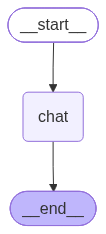

In [14]:
builder = StateGraph(MessagesState)
builder.add_node("chat", chat_node)
builder.add_edge(START, "chat")
builder.add_edge("chat", END)

graph = builder.compile(store=store)

graph

In [16]:
config = {"configurable": {"user_id": "u1"}}

result = graph.invoke(
    {"messages": [{"role": "user", "content": "Explain gen ai in simple terms."}]},
    config,
)

print(result["messages"][-1].content)

Sure, I'd be happy to explain generative AI in simple terms!

Generative AI refers to a type of artificial intelligence that can create new content, such as text, images, music, or even videos. Instead of just analyzing or processing data, generative AI learns patterns from existing data and then uses that knowledge to generate something new. 

For example, if you train a generative AI model on a collection of paintings, it can create a new painting by mimicking styles it has learned from the existing artwork. Similarly, if it’s trained on lots of text, it can write stories or articles that sound like they were written by a human.

In short, generative AI is like a creative partner that uses what it's learned from existing examples to create fresh, new pieces of content.

If you have any specific area of generative AI you're curious about, let me know!

Here are a few questions you might consider:
1. Are you interested in how generative AI is used in specific applications, like art or 

## Chatbot Creating New Memories

In [19]:
store = InMemoryStore()

In [21]:
# LLM that decides what to remember (structured output)
extractor_llm = ChatOpenAI(model="gpt-4o-mini", temperature=0)

In [22]:
class MemoryDecision(BaseModel):
    should_write: bool = Field(description="Whether to store any memories")
    memories: list[str] = Field(default_factory=list, description="Atomic user memories to store")

In [23]:
memory_extractor = extractor_llm.with_structured_output(MemoryDecision)

In [ ]:
#    (Creates memories, but does NOT use them to answer)
# ----------------------------
def remember_only_node(state: MessagesState, config: RunnableConfig, store: BaseStore):

    user_id = config["configurable"]["user_id"]
    
    namespace = ("user", user_id, "details")

    # take latest user message
    last_msg = state["messages"][-1].content

    # LLM decides what to store
    decision: MemoryDecision = memory_extractor.invoke( 
        [
            SystemMessage(
                content=(
                    "Extract LONG-TERM memories from the user's message.\n"
                    "Only store stable, user-specific info (identity, preferences, ongoing projects).\n"
                    "Do NOT store transient info.\n"
                    "Return should_write=false if nothing is worth storing.\n"
                    "Each memory should be a short atomic sentence."
                )
            ),
            {"role": "user", "content": last_msg},
        ]
    )

    # Write to store (LTM)
    if decision.should_write:
        for mem in decision.memories:
            store.put(namespace, str(uuid.uuid4()), {"data": mem})

    # IMPORTANT: we are NOT using memory, not even responding with the LLM.
    # We just return a fixed acknowledgement.
    return {"messages": [{"role": "assistant", "content": "Noted."}]}

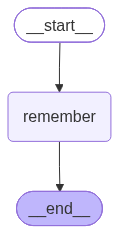

In [26]:
builder = StateGraph(MessagesState)
builder.add_node("remember", remember_only_node)
builder.add_edge(START, "remember")
builder.add_edge("remember", END)

graph = builder.compile(store=store)

graph

In [28]:
config = {"configurable": {"user_id": "u1"}}

res = graph.invoke({"messages": [{"role": "user", "content": "Hi my name is Rohit"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [29]:
res = graph.invoke({"messages": [{"role": "user", "content": "I teach AI on youtube"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [30]:
res = graph.invoke({"messages": [{"role": "user", "content": "My favorite programming language is Python"}]},config)
print("Assistant:", res["messages"][-1].content)

Assistant: Noted.


In [31]:
items = store.search(("user", "u1", "details"))

for item in items:
    print(item.value['data'])

User's name is Nitish.
User's name is Rohit.
User teaches AI on YouTube.
User's favorite programming language is Python.
